## Race Position Predictability Modeling

This notebook builds a **predictability curve** — how accurately a driver's final finishing-position bucket can be predicted from the state of the race at various lap checkpoints — and compares **2024 vs 2025**.

Pipeline:
1. Load each race session once via FastF1.
2. Extract per-driver features at every lap checkpoint (current position, tyre compound & age, stint, pit stops so far, gap to leader, 3-lap pace delta vs the field).
3. Use **leave-one-race-out cross-validation** (GroupKFold by Grand Prix) to train a `RandomForestClassifier` per lap checkpoint and report held-out accuracy.
4. Compare against a **majority-class baseline** (empirical class prior), not a uniform 25% baseline.

Cell 1 below is setup only. The modeling pipeline is defined in the cells that follow and executed in the final cell.

In [9]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fastf1
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')

os.makedirs('fastf1_cache', exist_ok=True)
fastf1.Cache.enable_cache('fastf1_cache')

LAP_CHECKPOINTS = [5, 10, 20, 30, 40, 50]
POSITION_BINS = [0, 3, 6, 10, 99]
POSITION_LABELS = ['Podium (P1-P3)', 'Top Points (P4-P6)', 'Low Points (P7-P10)', 'Out of Points (P11+)']


# Race Position Prediction: 2024 vs 2025 Analysis

## Objective
Determine at what point in a Formula 1 race a driver's final finishing-position bucket can be predicted with high accuracy, and how this predictive confidence evolves over the race. By running the same pipeline on 2024 and 2025, we can ask whether the product has become more or less predictable year-over-year.

## Methodology

### 1. Data Acquisition
Use the **FastF1** Python API. Each race session is loaded **once per year** and features are extracted at every lap checkpoint in a single pass.

### 2. Feature Engineering (State at Lap $N$)
For each driver, frozen at the end of lap $N$:
- **Current Position** (used as a diagnostic feature only; the headline model excludes it to avoid target leakage, since `Position` at late laps is essentially the final bucket).
- **Tyre Compound & Age** (`Compound` one-hot, `TyreLife`).
- **Stint** number.
- **Pit Stops Taken So Far** (cumulative count of laps with a non-null `PitInTime`).
- **Gap to Leader** at lap $N$ (session time delta vs. the driver with the smallest session time at that lap).
- **Pace Delta** over the last 3 clean (non-pit) laps — driver's median lap time minus the field median.

### 3. Target Variable
Final finishing position taken from the **FIA classified results** (`session.results`), grouped into four buckets:
- **Podium (P1–P3), Top Points (P4–P6), Low Points (P7–P10), Out of Points (P11+).**

Using classified results (not the driver's last recorded lap) correctly handles DNFs.

### 4. Modeling Approach
- **Algorithm:** `RandomForestClassifier` (non-linear, tolerant of mixed scales).
- **Evaluation:** **GroupKFold leave-one-race-out** cross-validation at each lap checkpoint. A separate model is trained and evaluated per checkpoint; drivers from the same race never appear in both train and test.
- **Baseline:** Empirical majority-class accuracy per year (not a uniform 25% line), since the bucket priors are very unequal.

---

### Feature Extraction

In [10]:
def _classified_final_positions(session) -> pd.Series:
    """Return DriverNumber (str) -> FIA classified finishing position."""
    results = session.results.copy()
    results.index = results.index.astype(str)
    return results['Position']


def extract_race_features(year: int, grand_prix: str, lap_checkpoints=LAP_CHECKPOINTS) -> pd.DataFrame | None:
    """
    Load a race session once and extract per-driver features at every lap checkpoint.

    Returns a long-form DataFrame with one row per (driver, lap_checkpoint):
        Year, GrandPrix, LapCheckpoint, DriverNumber,
        Position, Compound, TyreLife, Stint,
        PitStopsSoFar, GapToLeader, PaceDelta3, FinalPosition
    """
    try:
        session = fastf1.get_session(year, grand_prix, 'R')
        session.load(telemetry=False, weather=False, messages=False)
    except Exception as e:
        print(f"Failed to load {year} {grand_prix}: {e}")
        return None

    laps = session.laps
    if laps.empty:
        print(f"No laps for {year} {grand_prix}")
        return None

    final_pos = _classified_final_positions(session)

    laps = laps.sort_values(['DriverNumber', 'LapNumber']).copy()
    laps['DriverNumber'] = laps['DriverNumber'].astype(str)
    laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()
    laps['TimeSec'] = laps['Time'].dt.total_seconds()
    laps['IsPitLap'] = laps['PitInTime'].notna() | laps['PitOutTime'].notna()
    laps['PitInFlag'] = laps['PitInTime'].notna().astype(int)
    laps['PitStopsSoFar'] = laps.groupby('DriverNumber')['PitInFlag'].cumsum()

    rows = []
    for lap_n in lap_checkpoints:
        at_lap = laps[laps['LapNumber'] == lap_n].copy()
        if at_lap.empty:
            continue

        leader_time = at_lap['TimeSec'].min(skipna=True)
        at_lap['GapToLeader'] = at_lap['TimeSec'] - leader_time

        window = laps[(laps['LapNumber'] <= lap_n) & (laps['LapNumber'] > lap_n - 3) & (~laps['IsPitLap'])]
        if not window.empty:
            field_median = window['LapTimeSec'].median()
            driver_pace = window.groupby('DriverNumber')['LapTimeSec'].median().rename('DriverPace')
            at_lap = at_lap.merge(driver_pace, on='DriverNumber', how='left')
            at_lap['PaceDelta3'] = at_lap['DriverPace'] - field_median
        else:
            at_lap['PaceDelta3'] = np.nan

        at_lap['Year'] = year
        at_lap['GrandPrix'] = grand_prix
        at_lap['LapCheckpoint'] = lap_n
        at_lap['FinalPosition'] = at_lap['DriverNumber'].map(final_pos)

        cols = [
            'Year', 'GrandPrix', 'LapCheckpoint', 'DriverNumber',
            'Position', 'Compound', 'TyreLife', 'Stint',
            'PitStopsSoFar', 'GapToLeader', 'PaceDelta3', 'FinalPosition',
        ]
        rows.append(at_lap[cols])

    if not rows:
        return None
    return pd.concat(rows, ignore_index=True)

### Training the Classifier

For each lap checkpoint we fit an independent `RandomForestClassifier` and evaluate with **leave-one-race-out** `GroupKFold` (groups = Grand Prix). This guarantees that the drivers being scored come from a race the model has never seen.

By default we **exclude `Position`** from the feature set: at late laps it is nearly identical to the final bucket and collapses the model into the identity function, producing artificially high accuracy. A helper also computes the **majority-class baseline** from the empirical bucket distribution.

In [11]:
BASE_NUMERIC_FEATURES = ['TyreLife', 'Stint', 'PitStopsSoFar', 'GapToLeader', 'PaceDelta3']


def assign_bucket(series: pd.Series) -> pd.Series:
    return pd.cut(series, bins=POSITION_BINS, labels=POSITION_LABELS, right=True)


def majority_class_baseline(df: pd.DataFrame) -> float:
    """Empirical accuracy of always predicting the most common bucket."""
    buckets = assign_bucket(df['FinalPosition']).dropna()
    if buckets.empty:
        return float('nan')
    return buckets.value_counts(normalize=True).max()


def evaluate_predictability(df_year: pd.DataFrame, lap_checkpoints=LAP_CHECKPOINTS,
                            include_position: bool = False) -> dict[int, dict]:
    """
    For each lap checkpoint, train a RandomForestClassifier with leave-one-race-out
    GroupKFold CV and return mean/std/SE plus per-race fold accuracies.
    """
    df = df_year.copy()
    df['PosBucket'] = assign_bucket(df['FinalPosition'])
    df = df.dropna(subset=['PosBucket'])

    results: dict[int, dict] = {}

    for lap_n in lap_checkpoints:
        empty = {'mean': float('nan'), 'std': float('nan'), 'se': float('nan'),
                 'n_folds': 0, 'fold_accs': {}}
        sub = df[df['LapCheckpoint'] == lap_n].copy()
        if sub.empty:
            results[lap_n] = empty
            continue

        sub = pd.get_dummies(sub, columns=['Compound'], dummy_na=False)
        compound_cols = [c for c in sub.columns if c.startswith('Compound_')]
        feature_cols = (['Position'] if include_position else []) + BASE_NUMERIC_FEATURES + compound_cols

        sub = sub.dropna(subset=feature_cols + ['PosBucket'])
        if sub['GrandPrix'].nunique() < 2 or len(sub) < 10:
            results[lap_n] = empty
            continue

        X = sub[feature_cols].astype(float)
        y = sub['PosBucket'].astype(str)
        groups = sub['GrandPrix']

        gkf = GroupKFold(n_splits=groups.nunique())
        fold_accs: dict[str, float] = {}
        for train_idx, test_idx in gkf.split(X, y, groups):
            if pd.Series(y.iloc[train_idx]).nunique() < 2:
                continue
            held_race = groups.iloc[test_idx].iloc[0]
            rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
            rf.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = rf.predict(X.iloc[test_idx])
            fold_accs[held_race] = accuracy_score(y.iloc[test_idx], preds)

        if not fold_accs:
            results[lap_n] = empty
            continue

        arr = np.array(list(fold_accs.values()))
        results[lap_n] = {
            'mean': float(arr.mean()),
            'std': float(arr.std(ddof=1)) if len(arr) > 1 else 0.0,
            'se': float(arr.std(ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0,
            'n_folds': int(len(arr)),
            'fold_accs': fold_accs,
        }

    return results


def paired_permutation_test(accs_a: list[float], accs_b: list[float],
                            n_perm: int = 10000, seed: int = 42) -> dict:
    """
    Two-sided paired permutation test on matched-sample differences a - b.
    Returns mean_diff and the p-value under the null of exchangeable signs.
    """
    if len(accs_a) != len(accs_b) or len(accs_a) < 2:
        return {'mean_diff': float('nan'), 'p_value': float('nan'), 'n_pairs': len(accs_a)}
    rng = np.random.default_rng(seed)
    diffs = np.asarray(accs_a) - np.asarray(accs_b)
    obs = float(diffs.mean())
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(diffs)))
    perm_means = (signs * diffs).mean(axis=1)
    p = float((np.abs(perm_means) >= abs(obs) - 1e-12).mean())
    return {'mean_diff': obs, 'p_value': p, 'n_pairs': len(diffs)}

### Predictability Curve (2024 vs 2025)

Each race session is loaded **once** and features for every checkpoint are extracted together. For each year we then run the leave-one-race-out evaluation per checkpoint, print the accuracy table alongside the majority-class baseline, and overlay both seasons' curves.

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



--- Loading 2024 data ---


core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached 

2024: 24 races, 2,672 (driver, checkpoint) rows

--- Loading 2025 data ---


core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '16', '4', '63', '12', '44', '55', '23', '6', '14', '30', '87', '31', '27', '18', '7', '5', '22', '10']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached da

2025: 24 races, 2,668 (driver, checkpoint) rows

MAIN (Position excluded) — leave-one-race-out CV, mean ± SE:
Lap                         2024                      2025
----------------------------------------------------------
5           61.61% ± 3.55%  (n=24)      60.36% ± 3.94%  (n=22)
10          62.06% ± 3.97%  (n=24)      58.56% ± 3.83%  (n=23)
20          68.60% ± 2.99%  (n=24)      65.24% ± 3.42%  (n=23)
30          62.26% ± 3.92%  (n=24)      69.90% ± 3.12%  (n=24)
40          69.40% ± 3.61%  (n=24)      63.78% ± 3.90%  (n=24)
50          66.55% ± 3.50%  (n=23)      63.25% ± 4.25%  (n=23)

DIAGNOSTIC (Position included) — should climb toward ~100% at late laps:
Lap                         2024                      2025
----------------------------------------------------------
5           68.43% ± 3.58%  (n=24)      64.31% ± 3.18%  (n=22)
10          67.92% ± 3.21%  (n=24)      63.72% ± 3.76%  (n=23)
20          70.78% ± 2.62%  (n=24)      68.82% ± 3.15%  (n=23)
30          7

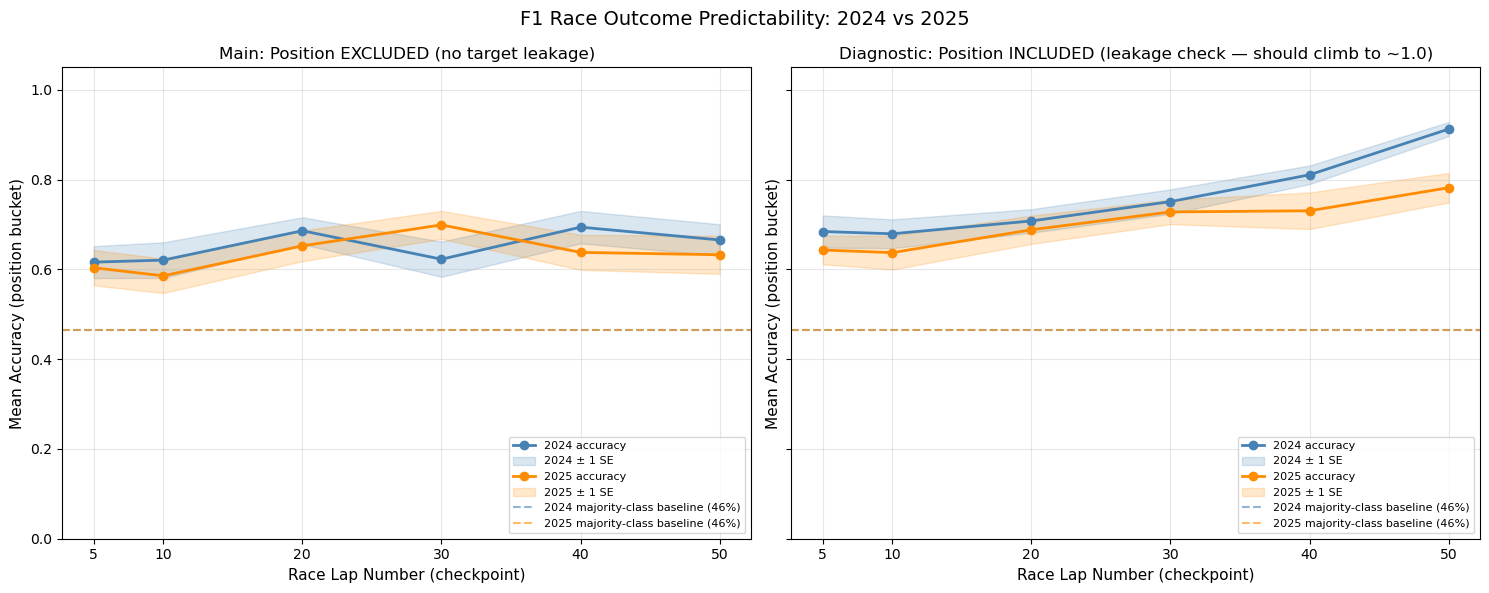

In [12]:
YEAR_COLORS = {2024: 'steelblue', 2025: 'darkorange'}


def build_feature_dataset(year: int, races_list: list[str],
                         lap_checkpoints=LAP_CHECKPOINTS) -> pd.DataFrame:
    frames = []
    for gp in races_list:
        feat = extract_race_features(year, gp, lap_checkpoints)
        if feat is not None and not feat.empty:
            frames.append(feat)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def _print_table(results_by_year: dict, years, lap_checkpoints, title: str):
    header = f"{'Lap':<6}" + "".join(f"{y:>26}" for y in years)
    print(f"\n{title}")
    print(header)
    print("-" * len(header))
    for lap in lap_checkpoints:
        row = f"{lap:<6}"
        for y in years:
            r = results_by_year[y].get(lap, {'mean': float('nan'), 'se': float('nan'), 'n_folds': 0})
            if np.isnan(r['mean']):
                row += f"{'n/a':>26}"
            else:
                row += f"{r['mean']:>12.2%} ± {r['se']:>5.2%}  (n={r['n_folds']:>2})"
        print(row)


def _plot_panel(ax, results_by_year, baselines, years, lap_checkpoints, title: str):
    for y in years:
        means = np.array([results_by_year[y].get(lap, {}).get('mean', np.nan) for lap in lap_checkpoints])
        ses = np.array([results_by_year[y].get(lap, {}).get('se', np.nan) for lap in lap_checkpoints])
        color = YEAR_COLORS.get(y)
        ax.plot(lap_checkpoints, means, marker='o', linewidth=2, color=color, label=f'{y} accuracy')
        ax.fill_between(lap_checkpoints, means - ses, means + ses, color=color, alpha=0.2,
                        label=f'{y} ± 1 SE')
    for y in years:
        b = baselines[y]
        if not np.isnan(b):
            ax.axhline(b, linestyle='--', alpha=0.6, color=YEAR_COLORS.get(y),
                       label=f'{y} majority-class baseline ({b:.0%})')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Race Lap Number (checkpoint)', fontsize=11)
    ax.set_ylabel('Mean Accuracy (position bucket)', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(lap_checkpoints)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)


def run_comparison_analysis(races_list: list[str],
                            years=(2024, 2025),
                            lap_checkpoints=LAP_CHECKPOINTS):
    data: dict[int, pd.DataFrame] = {}
    for year in years:
        print(f"\n--- Loading {year} data ---")
        df = build_feature_dataset(year, races_list, lap_checkpoints)
        data[year] = df
        if df.empty:
            print(f"No data loaded for {year}")
        else:
            print(f"{year}: {df['GrandPrix'].nunique()} races, {len(df):,} (driver, checkpoint) rows")

    baselines = {y: (majority_class_baseline(df) if not df.empty else float('nan'))
                 for y, df in data.items()}

    main_results = {
        y: (evaluate_predictability(df, lap_checkpoints, include_position=False) if not df.empty
            else {lap: {'mean': float('nan'), 'std': float('nan'), 'se': float('nan'),
                         'n_folds': 0, 'fold_accs': {}} for lap in lap_checkpoints})
        for y, df in data.items()
    }
    diag_results = {
        y: (evaluate_predictability(df, lap_checkpoints, include_position=True) if not df.empty
            else {lap: {'mean': float('nan'), 'std': float('nan'), 'se': float('nan'),
                         'n_folds': 0, 'fold_accs': {}} for lap in lap_checkpoints})
        for y, df in data.items()
    }

    _print_table(main_results, years, lap_checkpoints,
                 "MAIN (Position excluded) — leave-one-race-out CV, mean ± SE:")
    _print_table(diag_results, years, lap_checkpoints,
                 "DIAGNOSTIC (Position included) — should climb toward ~100% at late laps:")

    print()
    for y in years:
        b = baselines[y]
        if not np.isnan(b):
            print(f"Majority-class baseline {y}: {b:.2%}")

    print("\nPaired permutation test (2024 − 2025) on per-race fold accuracies, main model:")
    print(f"{'Lap':<6}{'mean diff':>14}{'p-value':>12}{'n pairs':>12}")
    print("-" * 44)
    if len(years) == 2:
        y_a, y_b = years
        for lap in lap_checkpoints:
            fa = main_results[y_a][lap].get('fold_accs', {})
            fb = main_results[y_b][lap].get('fold_accs', {})
            common = sorted(set(fa) & set(fb))
            if len(common) < 2:
                print(f"{lap:<6}{'n/a':>14}{'n/a':>12}{len(common):>12}")
                continue
            a_vals = [fa[r] for r in common]
            b_vals = [fb[r] for r in common]
            res = paired_permutation_test(a_vals, b_vals, n_perm=10000)
            print(f"{lap:<6}{res['mean_diff']:>13.2%} {res['p_value']:>12.3f}{res['n_pairs']:>12}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    _plot_panel(axes[0], main_results, baselines, years, lap_checkpoints,
                'Main: Position EXCLUDED (no target leakage)')
    _plot_panel(axes[1], diag_results, baselines, years, lap_checkpoints,
                'Diagnostic: Position INCLUDED (leakage check — should climb to ~1.0)')
    fig.suptitle('F1 Race Outcome Predictability: 2024 vs 2025', fontsize=14)
    fig.tight_layout()
    fig.savefig('predictability_curve_2024_vs_2025.png', dpi=150)
    plt.show()

    return data, main_results, diag_results, baselines


# Full shared 2024/2025 calendar. Races absent from a given year are skipped
# automatically by extract_race_features.
target_races = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China',
    'Miami', 'Emilia Romagna', 'Monaco', 'Canada', 'Spain',
    'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands',
    'Italy', 'Azerbaijan', 'Singapore', 'United States', 'Mexico',
    'Sao Paulo', 'Las Vegas', 'Qatar', 'Abu Dhabi',
]

data, main_results, diag_results, baselines = run_comparison_analysis(
    target_races, years=(2024, 2025)
)

## How to Read the Results
1. **Predictability curve shape.** Accuracy should rise with lap number: early on, pit-stop strategies and traffic dominate, while at later laps true pace crystallises the order. Because `Position` is excluded from the feature set, the curve must rise via the other features (pace delta, gap to leader, pit count, tyre state) — it will not collapse to 100% by construction.
2. **2024 vs 2025 comparison.** A flatter 2025 curve (or one sitting closer to its majority-class baseline) suggests a more competitive, harder-to-predict field. A 2025 curve above 2024 suggests the order becomes set earlier — e.g., one team pulling clear. Always interpret relative to each year's **own** majority-class baseline, shown as the dashed line of the matching colour.
3. **Diagnostic run.** To verify the `Position` leakage point, re-run with `include_position=True` — the curve will jump close to 100% at late laps, which is exactly the behaviour we are trying to avoid in the headline analysis.
4. **Caveats.** Only a handful of races per season are used by default; expand `target_races` for tighter estimates. Tracks that don't appear in both seasons are skipped per year but should ideally match across years for a fair comparison.